# EDA Interacciones con Soporte

## Introducción

En este análisis exploratorio se estudiará el comportamiento de las interacciones de soporte de los clientes.

El objetivo es identificar patrones relacionados con:
- canales de contacto,
- motivos de interacción,
- satisfacción del cliente,
- incidencias,
- tiempos de resolución,
- y posibles señales relacionadas con churn.

## Librerías

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

Cargamos el dataset de interacciones con soporte y realizamos una primera inspección de su estructura.

In [4]:
path_soporte = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


# Relación entre interacciones de soporte y churn

El dataset `interacciones_soporte.csv` tampoco vive en el mismo nivel que `churn_target.csv`.

- `interacciones_soporte.csv` tiene múltiples filas por cliente, ya que un mismo cliente puede contactar varias veces con soporte.
- `churn_target.csv` tiene una estructura temporal cliente-mes.

Por tanto, no es correcto realizar una unión directa y tratar ambos datasets como si representaran el mismo nivel analítico.

Para este EDA construiremos una etiqueta agregada por cliente:

- `ever_churn = 1` si el cliente churnea al menos una vez durante el periodo observado.
- `ever_churn = 0` en caso contrario.

Esto permitirá analizar si determinados patrones de soporte:
- mayor número de interacciones,
- incidencias repetidas,
- baja satisfacción,
- contactos por baja o portabilidad,
- o problemas de facturación

aparecen con más frecuencia en clientes que terminan abandonando.

Sin embargo, esta aproximación tiene una limitación importante:
la dimensión temporal queda agregada en una única etiqueta.

Por tanto, este enfoque es útil para exploración y análisis descriptivo, pero no sustituye un modelado temporal riguroso orientado a predicción de churn.

In [5]:
# ==========================================
# Cargar churn_target
# ==========================================

path_churn = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\churn_target.csv'

churn = pd.read_csv(path_churn)

print('churn_target:', churn.shape)

display(churn.head())

churn_target: (321987, 3)


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [6]:
# ==========================================
# Construcción variable ever_churn
# ==========================================

ever_churn = (
    churn
    .groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

ever_churn = ever_churn.rename(
    columns={'churn': 'ever_churn'}
)

display(ever_churn.head())

,cliente_id,ever_churn
0,C000001,0
1,C000002,0
2,C000003,1
3,C000004,0
4,C000005,0


In [7]:
# ==========================================
# Unión con interacciones soporte
# ==========================================

soporte_churn = soporte.merge(
    ever_churn,
    on='cliente_id',
    how='left'
)

print(soporte_churn.shape)

display(soporte_churn.head())

(308487, 14)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0,0


In [8]:
# ==========================================
# Distribución churn
# ==========================================

soporte_churn['ever_churn'] \
    .value_counts()

ever_churn
0    269735
1     38752
Name: count, dtype: int64

In [9]:
(
    soporte_churn['ever_churn']
    .value_counts(normalize=True) * 100
)

ever_churn
0    87.438044
1    12.561956
Name: proportion, dtype: float64

## Secciones

## Conclusiones

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   interaccion_id         308487 non-null  str    
 1   cliente_id             308487 non-null  str    
 2   fecha_evento           308487 non-null  str    
 3   mes                    308487 non-null  str    
 4   canal                  308487 non-null  str    
 5   motivo                 303847 non-null  str    
 6   duracion_min           308487 non-null  float64
 7   resuelto               308487 non-null  int64  
 8   satisfaccion_post      303858 non-null  float64
 9   stress_calidad_lag     308487 non-null  float64
 10  incidencia_masiva_lag  308487 non-null  int64  
 11  impago_mes             308487 non-null  int64  
 12  dias_retraso_mes       308487 non-null  int64  
dtypes: float64(3), int64(4), str(6)
memory usage: 49.3 MB
Categóricas: ['interaccion_id', 'cliente_id', 

,count,mean,std,min,25%,50%,75%,max
duracion_min,308487.0,6.017850,3.935398,-20.6,3.2000,5.900,8.6000,24.1000
satisfaccion_post,303858.0,3.444882,1.004027,1.0,3.0000,3.000,4.0000,5.0000
stress_calidad_lag,308487.0,0.450733,0.161818,0.0,0.3511,0.439,0.5437,0.8009
dias_retraso_mes,308487.0,7.074013,12.767853,0.0,0.0000,0.000,11.0000,64.0000


Duplicados: 4558


...

resuelto
1    177417
0    131070
Name: count, dtype: int64



impago_mes


impago_mes
0    225044
1     83443
Name: count, dtype: int64



incidencia_masiva_lag


incidencia_masiva_lag
0    306411
1      2076
Name: count, dtype: int64

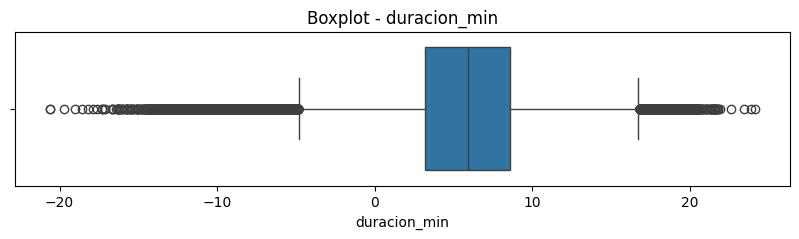

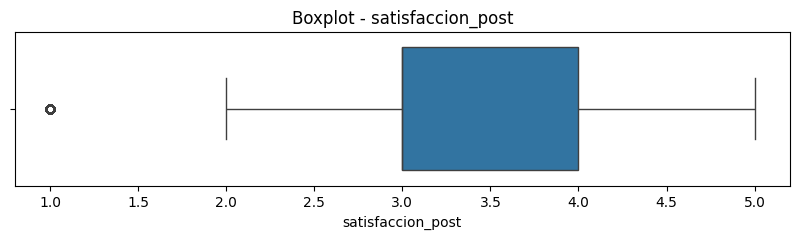

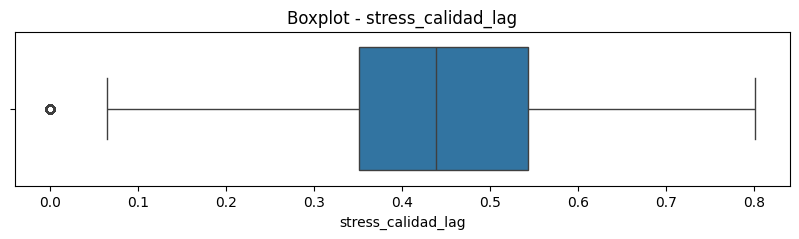

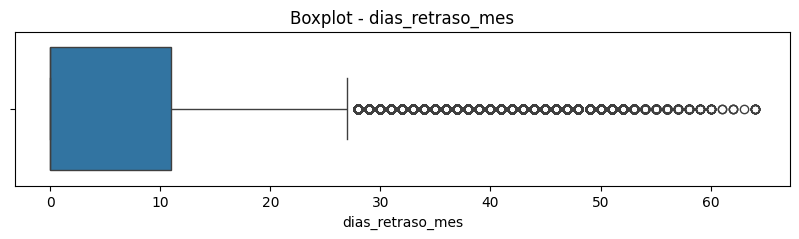

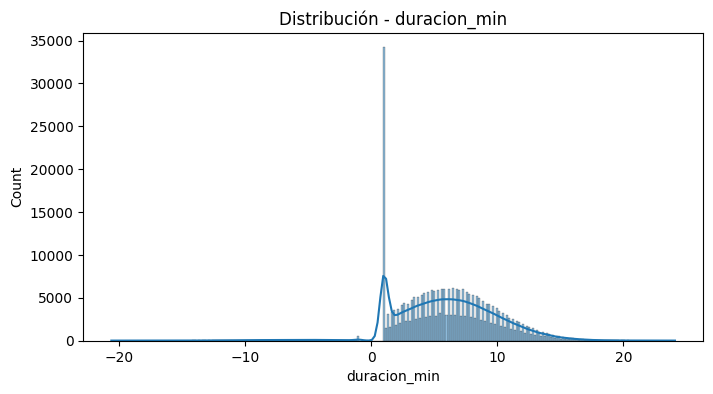

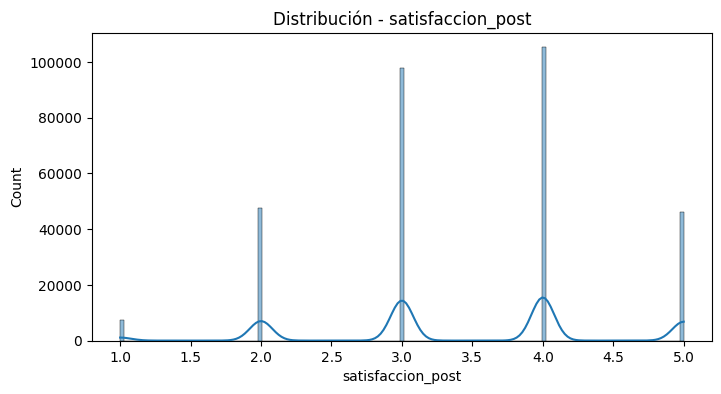

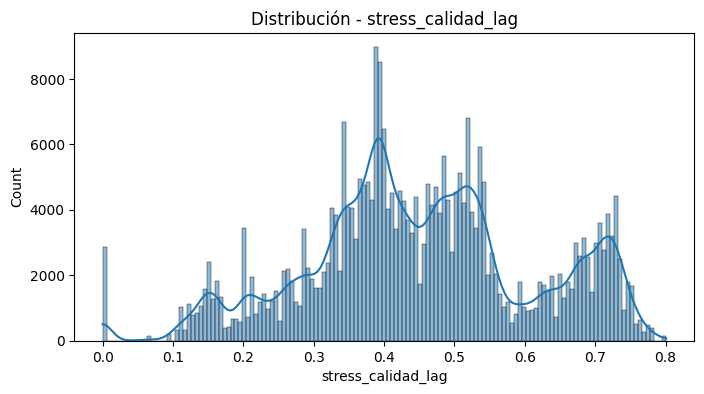

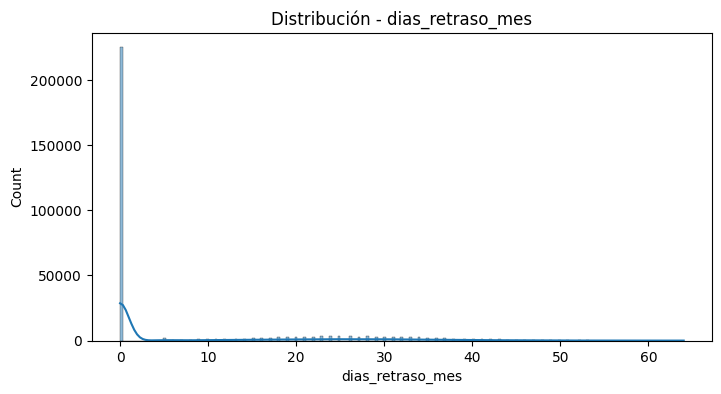

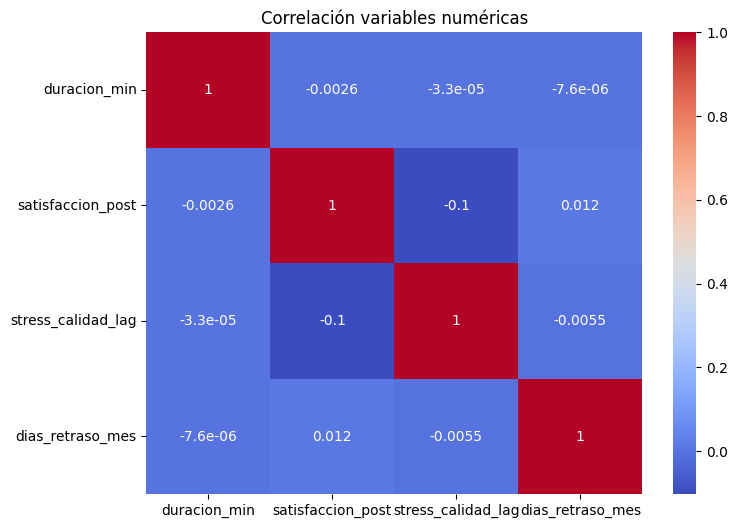

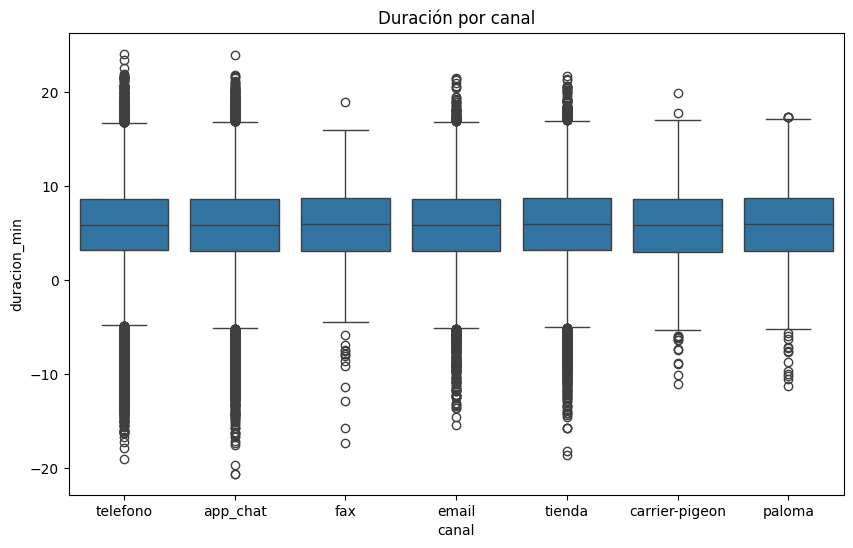

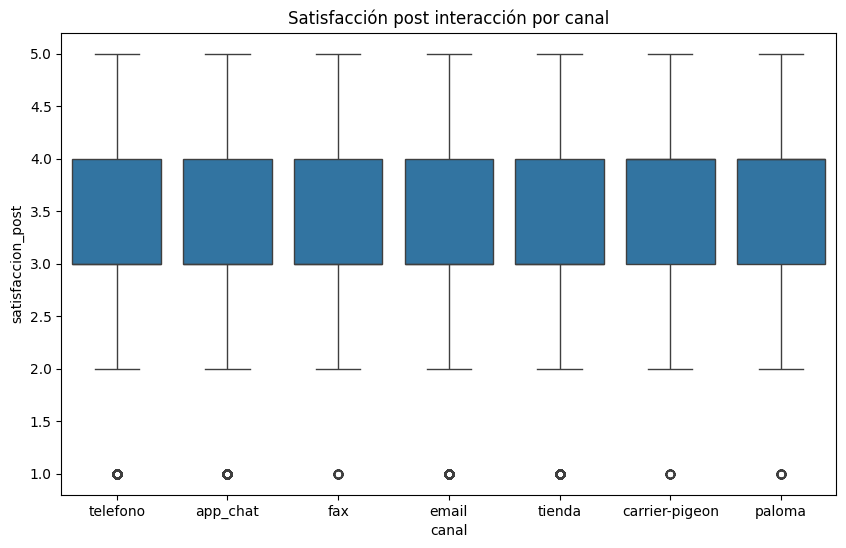

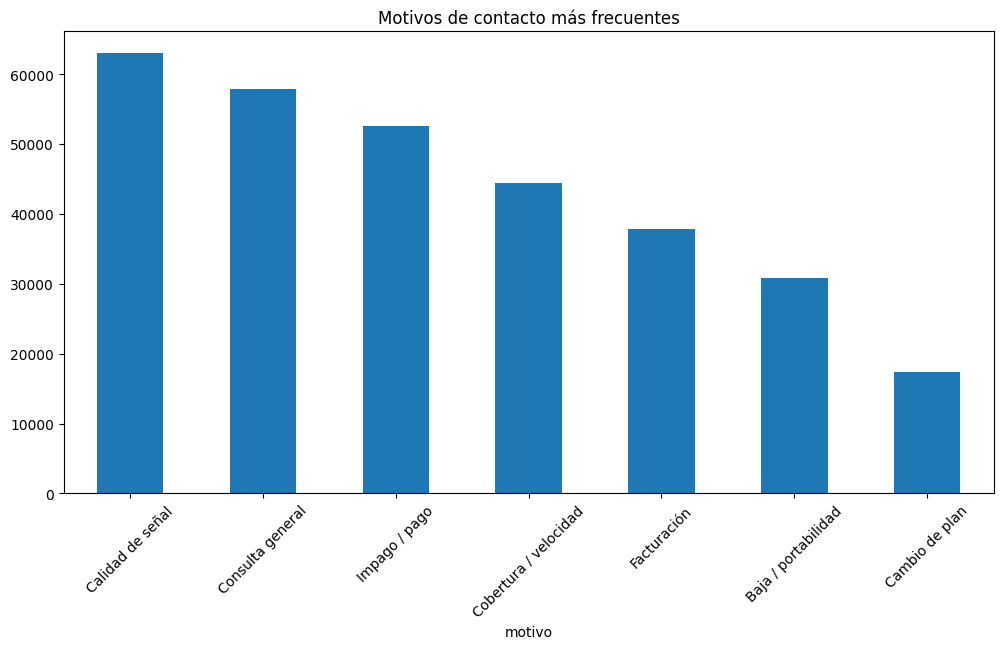

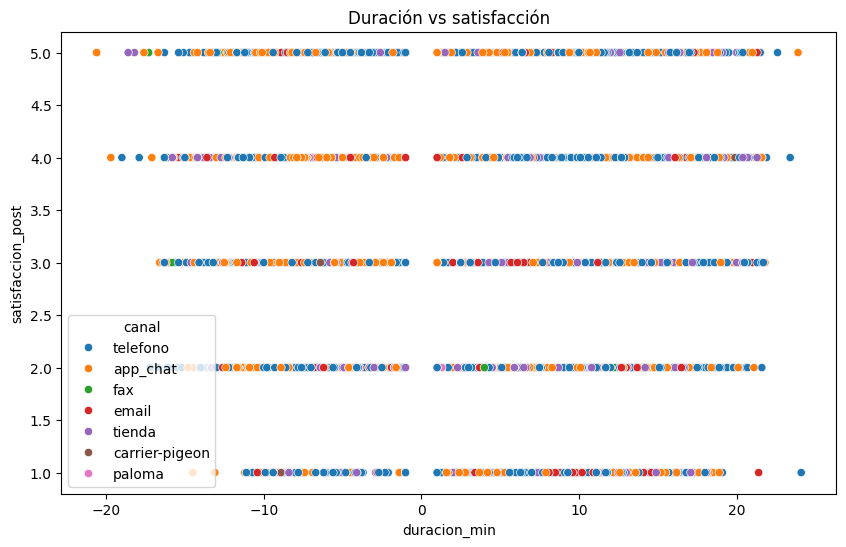

cliente_id
C005384    84
C004160    79
C008164    79
C004938    78
C008291    78
C003079    77
C000351    76
C000786    73
C002323    73
C003705    73
Name: count, dtype: int64

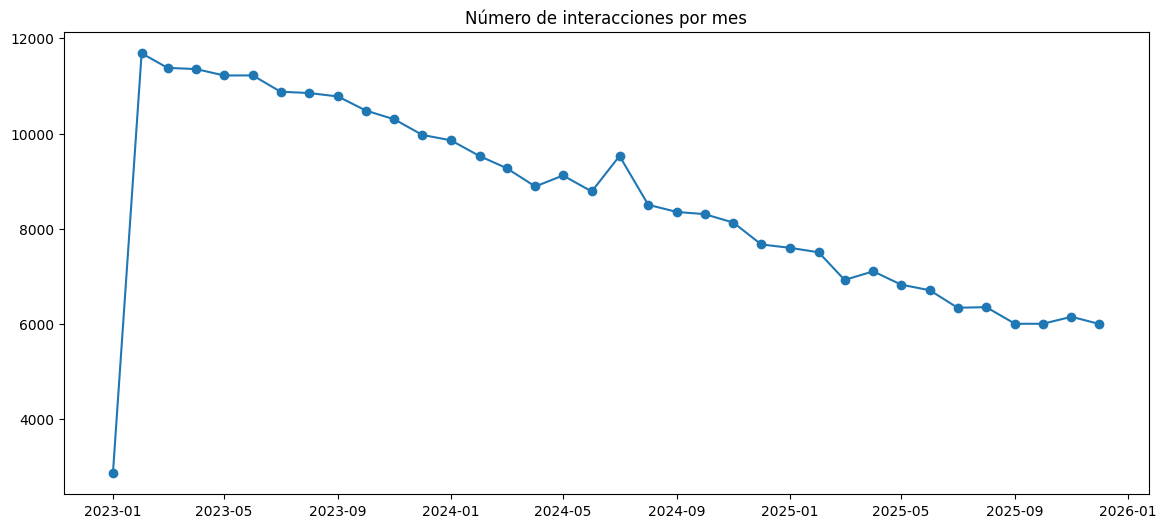

In [2]:
# ==========================================
# EDA - Interacciones con soporte
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Cargar dataset
# ==========================================

path_soporte = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())


# ==========================================
# Información general
# ==========================================

soporte.info()


# ==========================================
# Conversión de fechas
# ==========================================

soporte['fecha_evento'] = pd.to_datetime(
    soporte['fecha_evento'],
    format='mixed'
)

soporte['mes'] = pd.to_datetime(
    soporte['mes'],
    format='mixed'
)


# ==========================================
# Separación de variables
# ==========================================

soporte_cat_cols = [
    'interaccion_id',
    'cliente_id',
    'canal',
    'motivo',
    'resuelto',
    'incidencia_masiva_lag',
    'impago_mes'
]

soporte_num_cols = [
    'duracion_min',
    'satisfaccion_post',
    'stress_calidad_lag',
    'dias_retraso_mes'
]

soporte_date_cols = [
    'fecha_evento',
    'mes'
]

print('Categóricas:', soporte_cat_cols)
print('Numéricas:', soporte_num_cols)
print('Temporales:', soporte_date_cols)


# ==========================================
# Descriptivo numérico
# ==========================================

display(
    soporte[soporte_num_cols]
    .describe()
    .T
)


# ==========================================
# Duplicados
# ==========================================

print(
    'Duplicados:',
    soporte.duplicated().sum()
)

duplicados = soporte[
    soporte.duplicated(keep=False)
]

display(duplicados)


# ==========================================
# Valores nulos
# ==========================================

display(
    soporte.isnull().sum()
)


# ==========================================
# Distribución variables categóricas
# ==========================================

for col in [
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag'
]:
    
    print('\n')
    print(col)
    
    display(
        soporte[col]
        .value_counts(dropna=False)
    )


# ==========================================
# Boxplots variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(10,2))
    
    sns.boxplot(
        x=soporte[col]
    )
    
    plt.title(f'Boxplot - {col}')
    
    plt.show()


# ==========================================
# Histograms variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        soporte[col],
        kde=True
    )
    
    plt.title(f'Distribución - {col}')
    
    plt.show()


# ==========================================
# Correlación
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    soporte[soporte_num_cols]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación variables numéricas')

plt.show()


# ==========================================
# Análisis por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='duracion_min'
)

plt.title('Duración por canal')

plt.show()


# ==========================================
# Satisfacción por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='satisfaccion_post'
)

plt.title('Satisfacción post interacción por canal')

plt.show()


# ==========================================
# Motivos más frecuentes
# ==========================================

plt.figure(figsize=(12,6))

soporte['motivo'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Motivos de contacto más frecuentes')

plt.xticks(rotation=45)

plt.show()


# ==========================================
# Relación duración vs satisfacción
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=soporte,
    x='duracion_min',
    y='satisfaccion_post',
    hue='canal'
)

plt.title('Duración vs satisfacción')

plt.show()


# ==========================================
# Clientes con más interacciones
# ==========================================

top_clientes = (
    soporte['cliente_id']
    .value_counts()
    .head(10)
)

display(top_clientes)


# ==========================================
# Evolución temporal interacciones
# ==========================================

interacciones_mes = (
    soporte
    .groupby('mes')
    .size()
)

plt.figure(figsize=(14,6))

plt.plot(
    interacciones_mes.index,
    interacciones_mes.values,
    marker='o'
)

plt.title('Número de interacciones por mes')

plt.show()